<h2>K-Nearest Neighbours</h2>

In [4]:
load('.RData')

In [6]:
library(FSelector)
library(tidyverse)
library(RColorBrewer)
library(caret)

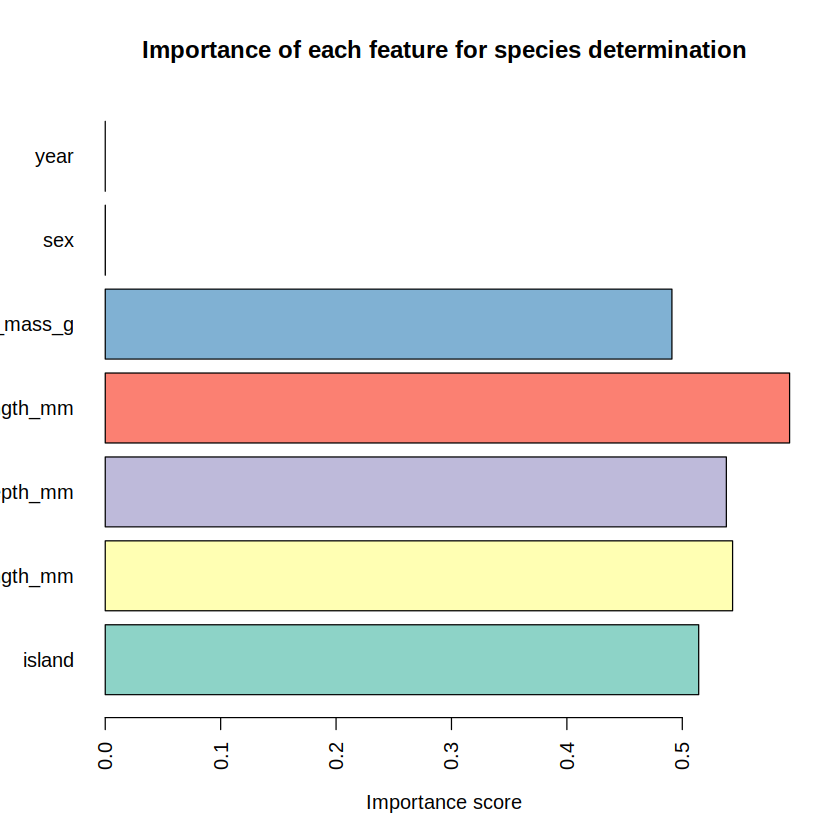

In [31]:
df <- na.omit(df_penguins)
df <- as.data.frame(df)
rownames(df) <- paste0(paste0(paste0(rownames(df), substr(df$species,1,1)), substr(df$island,1,1)), substr(df$sex,1,1))

importance <- information.gain(species~., df) 
barplot(importance[,1], main="Importance of each feature for species determination", 
        xlab="Importance score", names=rownames(importance), 
        col=brewer.pal(9, "Set3"),
        horiz=T, las=2)

#Sex y year no tiene relevancia en la determinacion de la especie

<h4>Data encoding</h4>
Es necesario codificar Island. Aplicamos One-Hot encoding

In [32]:
df_pen_enc <- df
df_pen_enc$island.Dream  <- ifelse(df_pen_enc$island == 'Dream', 1, 0)
df_pen_enc$island.Torgersen <- ifelse(df_pen_enc$island == 'Torgersen', 1, 0)
df_pen_enc$island <- NULL
df_pen_enc$sex <- NULL
df_pen_enc.sc <- as.data.frame(scale(df_pen_enc[, 2:5]))
df_pen_enc.sc$island.Dream <- df_pen_enc$island.Dream
df_pen_enc.sc$island.Torgersen <- df_pen_enc$island.Torgersen
df_pen_enc.sc$species <- df_pen_enc$species
head(df_pen_enc.sc)
### Bisco island ---> island.Dream = 0 y island.Torgersen = 0

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island.Dream,island.Torgersen,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1ATm,-0.8946955,0.7795590,-1.4246077,-0.5676206,0,1,Adelie
2ATf,-0.8215515,0.1194043,-1.0678666,-0.5055254,0,1,Adelie
3ATf,-0.6752636,0.4240910,-0.4257325,-1.1885721,0,1,Adelie
4ATf,-1.3335592,1.0842457,-0.5684290,-0.9401915,0,1,Adelie
5ATm,-0.8581235,1.7444004,-0.7824736,-0.6918109,0,1,Adelie
6ATf,-0.9312674,0.3225288,-1.4246077,-0.7228585,0,1,Adelie


In [33]:
set.seed(20)
index <- createDataPartition(df_pen_enc.sc$species, p = 0.75, list = FALSE)
train_data <- df_pen_enc.sc[index, ]
test_data <- df_pen_enc.sc[-index, ]
sprintf("The trainining set contains %d rows", nrow(train_data))
sprintf("The test set contains %d rows", nrow(test_data))

[1] "The trainining set contains 251 rows"

[1] "The test set contains 82 rows"

In [34]:
fit_control <- trainControl(## 10-fold CV
                           method = "repeatedcv",
                           number = 10,
                           ## repeated ten times
                           repeats = 10,
                           classProbs=TRUE)

In [35]:
table(train_data$species)

train_balanced <- upSample(x = train_data, y = train_data$species)
train_balanced = train_balanced[, !(colnames(train_balanced) %in% c("Class"))]

table(train_balanced$species)


   Adelie Chinstrap    Gentoo 
      110        51        90 


   Adelie Chinstrap    Gentoo 
      110       110       110 

In [36]:
knn <- train(species ~ ., data = train_balanced, 
             method = 'knn', 
             trControl = fit_control, metric = 'Accuracy')
knn

k-Nearest Neighbors 

330 samples
  6 predictor
  3 classes: 'Adelie', 'Chinstrap', 'Gentoo' 

No pre-processing
Resampling: Cross-Validated (10 fold, repeated 10 times) 
Summary of sample sizes: 297, 297, 297, 297, 297, 297, ... 
Resampling results across tuning parameters:

  k  Accuracy   Kappa    
  5  0.9875758  0.9813636
  7  0.9900000  0.9850000
  9  0.9945455  0.9918182

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was k = 9.

In [37]:
knn_preds <- predict(knn, newdata = test_data)
confusionMatrix(data = knn_preds, test_data$species)

Confusion Matrix and Statistics

           Reference
Prediction  Adelie Chinstrap Gentoo
  Adelie        36         1      0
  Chinstrap      0        16      0
  Gentoo         0         0     29

Overall Statistics
                                          
               Accuracy : 0.9878          
                 95% CI : (0.9339, 0.9997)
    No Information Rate : 0.439           
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.9808          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: Adelie Class: Chinstrap Class: Gentoo
Sensitivity                 1.0000           0.9412        1.0000
Specificity                 0.9783           1.0000        1.0000
Pos Pred Value              0.9730           1.0000        1.0000
Neg Pred Value              1.0000           0.9848        1.0000
Prevalence                  0.4390        

<h3>Knn aplicado a la determinacion del sexo</h3>

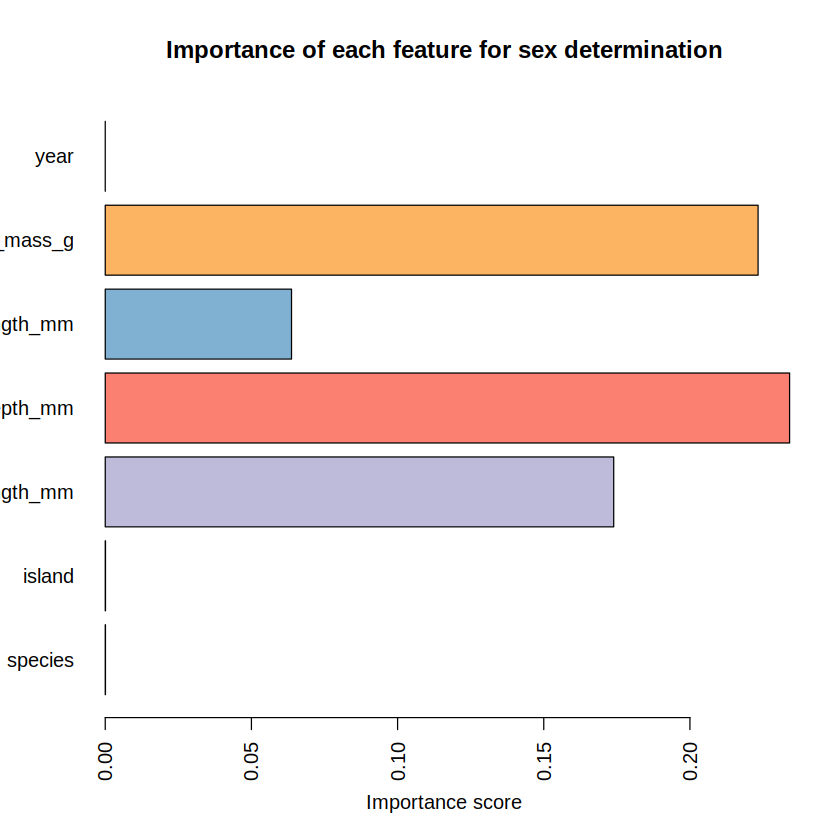

In [38]:
importance <- information.gain(sex~., df) 
barplot(importance[,1], main="Importance of each feature for sex determination", 
        xlab="Importance score", names=rownames(importance), 
        col=brewer.pal(9, "Set3"),
        horiz=T, las=2)
#Ni year, ni island, ni la especie son relevantes en la determinacion del sexo

In [50]:
#escalado de los datos
df_pen_enc <- df[, 3:7]
df_pen_enc.sc <- data.frame(scale(df_pen_enc[, 1:4]))
df_pen_enc.sc$sex <- df_pen_enc$sex
head(df_pen_enc.sc)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1ATm,-0.8946955,0.7795590,-1.4246077,-0.5676206,male
2ATf,-0.8215515,0.1194043,-1.0678666,-0.5055254,female
3ATf,-0.6752636,0.4240910,-0.4257325,-1.1885721,female
4ATf,-1.3335592,1.0842457,-0.5684290,-0.9401915,female
5ATm,-0.8581235,1.7444004,-0.7824736,-0.6918109,male
6ATf,-0.9312674,0.3225288,-1.4246077,-0.7228585,female


In [55]:
set.seed(42)
index <- createDataPartition(df_pen_enc.sc$sex, p = 0.75, list = FALSE)
train_data <- df_pen_enc.sc[index, ]
test_data <- df_pen_enc.sc[-index, ]
sprintf("The trainining set contains %d rows", nrow(train_data))
sprintf("The test set contains %d rows", nrow(test_data))

table(train_data$sex)

[1] "The trainining set contains 250 rows"

[1] "The test set contains 83 rows"


female   male 
   124    126 

In [56]:
fit_control <- trainControl(## 10-fold CV
                           method = "repeatedcv",
                           number = 10,
                           ## repeated ten times
                           repeats = 10,
                           classProbs=TRUE)

In [60]:
knn <- train(sex ~ ., data = train_data, 
             method = 'knn', 
             trControl = fit_control, metric = 'Accuracy')
knn

k-Nearest Neighbors 

250 samples
  4 predictor
  2 classes: 'female', 'male' 

No pre-processing
Resampling: Cross-Validated (10 fold, repeated 10 times) 
Summary of sample sizes: 225, 225, 225, 225, 225, 225, ... 
Resampling results across tuning parameters:

  k  Accuracy   Kappa    
  5  0.9028090  0.8054146
  7  0.9061077  0.8120385
  9  0.9058064  0.8114726

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was k = 7.

In [62]:
knn_preds <- predict(knn, newdata = test_data)
confusionMatrix(data = knn_preds, test_data$sex)

Confusion Matrix and Statistics

          Reference
Prediction female male
    female     38    3
    male        3   39
                                         
               Accuracy : 0.9277         
                 95% CI : (0.8493, 0.973)
    No Information Rate : 0.506          
    P-Value [Acc > NIR] : <2e-16         
                                         
                  Kappa : 0.8554         
                                         
 Mcnemar's Test P-Value : 1              
                                         
            Sensitivity : 0.9268         
            Specificity : 0.9286         
         Pos Pred Value : 0.9268         
         Neg Pred Value : 0.9286         
             Prevalence : 0.4940         
         Detection Rate : 0.4578         
   Detection Prevalence : 0.4940         
      Balanced Accuracy : 0.9277         
                                         
       'Positive' Class : female         
                                      

In [63]:
df_NA <- df_penguins[!complete.cases(df_penguins), ]
df_NA <- data.frame(df_NA[c(2:10), ])
rownames(df_NA) <- paste0('NA', rownames(df_NA))
df_NA 

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
NA1,Adelie,Torgersen,34.1,18.1,193,3475,NA,2007
NA2,Adelie,Torgersen,42.0,20.2,190,4250,NA,2007
NA3,Adelie,Torgersen,37.8,17.1,186,3300,NA,2007
NA4,Adelie,Torgersen,37.8,17.3,180,3700,NA,2007
NA5,Adelie,Dream,37.5,18.9,179,2975,NA,2007
NA6,Gentoo,Biscoe,44.5,14.3,216,4100,NA,2007
NA7,Gentoo,Biscoe,46.2,14.4,214,4650,NA,2008
NA8,Gentoo,Biscoe,47.3,13.8,216,4725,NA,2009
NA9,Gentoo,Biscoe,44.5,15.7,217,4875,NA,2009


In [68]:
df_NA.sc <- data.frame(scale(df_NA[, 3:6]))

knn_preds_na <- predict(knn, newdata = df_NA.sc)

df_NA$sex <- knn_preds_na
df_NA

#Comparando este resultado con el de logistic regresion, hay una diferencia en el
#pinguino NA4, aqui lo asigna male, y en el otro female

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
NA1,Adelie,Torgersen,34.1,18.1,193,3475,female,2007
NA2,Adelie,Torgersen,42.0,20.2,190,4250,male,2007
NA3,Adelie,Torgersen,37.8,17.1,186,3300,female,2007
NA4,Adelie,Torgersen,37.8,17.3,180,3700,male,2007
NA5,Adelie,Dream,37.5,18.9,179,2975,female,2007
NA6,Gentoo,Biscoe,44.5,14.3,216,4100,female,2007
NA7,Gentoo,Biscoe,46.2,14.4,214,4650,female,2008
NA8,Gentoo,Biscoe,47.3,13.8,216,4725,female,2009
NA9,Gentoo,Biscoe,44.5,15.7,217,4875,male,2009


In [69]:
save.image()